# Distance from Data Center Facilities to Nearest Historic Site

For each data center facility with known coordinates, finds the nearest National Register of Historic Places site using a BallTree haversine nearest-neighbor query. Run against the real facility list and NRHP data.

### Setup and load real data

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree

# ── ASSUMPTIONS ──────────────────────────────────────────────────────────────
# dc:   your dc_merged dataframe, columns: Latitude, Longitude
# nrhp: your nrhp_filtered_dc_counties dataframe, columns: latitude, longitude
# ─────────────────────────────────────────────────────────────────────────────

path_dc="DC_List (merge) files/dc_merged_updated_with_dates.csv"
path_nrhp="Distance_to_variables/nrhp_filtered_dc_counties_final.csv"

# Read the data from CSV files
dc = pd.read_csv(path_dc, encoding='latin-1')  # Use latin-1 encoding to handle special characters
nrhp = pd.read_csv(path_nrhp, encoding='latin-1')

### Clean and validate coordinates (steps 1-3)

In [2]:
# 1. Drop rows missing coordinates in either file
dc_geo = dc[dc['Latitude'].notna() & dc['Longitude'].notna()].copy()
nrhp_geo = nrhp[nrhp['latitude'].notna() & nrhp['longitude'].notna()].copy()

# 2. Convert coordinates to numeric (handles strings, errors, etc.)
dc_geo['Latitude'] = pd.to_numeric(dc_geo['Latitude'], errors='coerce')
dc_geo['Longitude'] = pd.to_numeric(dc_geo['Longitude'], errors='coerce')
nrhp_geo['latitude'] = pd.to_numeric(nrhp_geo['latitude'], errors='coerce')
nrhp_geo['longitude'] = pd.to_numeric(nrhp_geo['longitude'], errors='coerce')

# 3. Drop any rows where conversion failed
dc_geo = dc_geo[dc_geo['Latitude'].notna() & dc_geo['Longitude'].notna()].copy()
nrhp_geo = nrhp_geo[nrhp_geo['latitude'].notna() & nrhp_geo['longitude'].notna()].copy()

print(f"DC facilities with valid coords: {len(dc_geo)}")
print(f"NRHP sites with valid coords:    {len(nrhp_geo)}")

DC facilities with valid coords: 1277
NRHP sites with valid coords:    19360


### Nearest-neighbor distance via BallTree (steps 4-7)

In [3]:

# 4. Convert to radians for haversine
dc_rad   = np.radians(dc_geo[['Latitude',  'Longitude']].values)
nrhp_rad = np.radians(nrhp_geo[['latitude', 'longitude']].values)

# 5. Build BallTree on NRHP sites and query nearest neighbor
tree = BallTree(nrhp_rad, metric='haversine')
distances_rad, indices = tree.query(dc_rad, k=1)

# 6. Convert radians -> miles (Earth radius = 3958.8 mi)
distances_miles = distances_rad.flatten() * 3958.8
nearest_idx     = indices.flatten()

# 7. Pull name of nearest site for reference
nearest_names = nrhp_geo.iloc[nearest_idx]['Property Name'].values

# 8. Write results back to dc_geo
dc_geo['dist_nearest_nrhp_miles'] = distances_miles
dc_geo['nearest_nrhp_name']       = nearest_names

### Merge results and save (steps 8-9)

In [4]:

# 9. Merge back onto full dc dataframe (facilities missing coords get NaN)
dc_out = dc.merge(
    dc_geo[['dist_nearest_nrhp_miles', 'nearest_nrhp_name']],
    left_index=True, right_index=True, how='left'
)

print(f"\nDistance variable summary:")
print(dc_out['dist_nearest_nrhp_miles'].describe().round(3))
print(f"\nSample output:")
print(dc_out[['Facility_Name', 'dist_nearest_nrhp_miles', 'nearest_nrhp_name']].head(10).to_string())

dc_hist_var = dc_out[["Facility_number", "Facility_Name", "State", "County", "Street_Address", "Zip", 
                       "Latitude", "Longitude", "dist_nearest_nrhp_miles", "nearest_nrhp_name"]] 
dc_hist_var.to_csv("Distance_to_variables/dc_with_closest_nrhp_distance.csv", index=False)


Distance variable summary:
count    1277.000
mean       12.095
std       177.856
min         0.012
25%         1.496
50%         3.044
75%         6.687
max      6349.601
Name: dist_nearest_nrhp_miles, dtype: float64

Sample output:
                                                                               Facility_Name  dist_nearest_nrhp_miles                          nearest_nrhp_name
0                      Provident Realty Burns Harbor (100 Worthington Dr, Porter County, IN)                 2.687701                                 Cowles Bog
1            36MW Boutique Data Center Campus (140 W 5th Ave, Naperville, DuPage County, IL)                 9.835984          Lemont Downtown Historic District
2                                        1977 Saturn Data Center (HMC Capital / DigiCo LAX1)                 2.138509                    Montebello Woman's Club
3                             Chesterton Data Center Campus (200 Wren Ct, Porter County, IN)                 0.079284  New

## Visualization

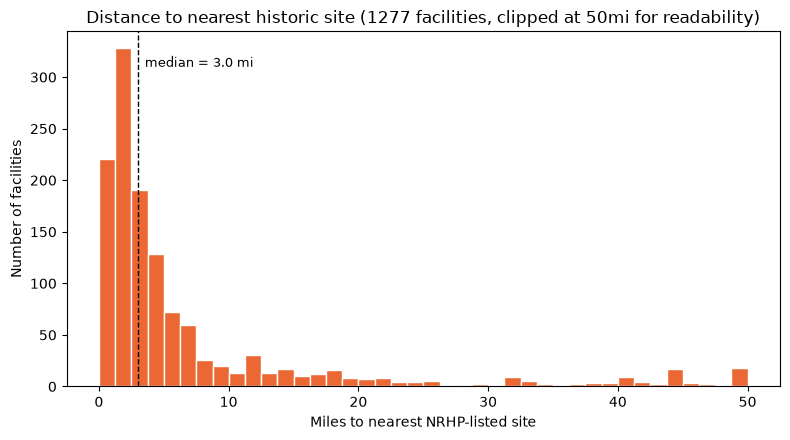

In [5]:

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10



import pandas as pd
df = pd.read_csv("Distance_to_variables/dc_with_closest_nrhp_distance.csv")
d = df["dist_nearest_nrhp_miles"].dropna()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(d.clip(upper=50), bins=40, color="#eb6834", edgecolor="white")
ax.set_title(f"Distance to nearest historic site ({len(d)} facilities, clipped at 50mi for readability)")
ax.set_xlabel("Miles to nearest NRHP-listed site")
ax.set_ylabel("Number of facilities")
median = d.median()
ax.axvline(median, color="black", linestyle="--", linewidth=1)
ax.text(median + 0.5, ax.get_ylim()[1]*0.9, f"median = {median:.1f} mi", fontsize=9)
plt.tight_layout()
plt.show()
